In [1]:
from __future__ import division, print_function, absolute_import, unicode_literals

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import least_squares
from scipy.optimize import leastsq
from scipy.spatial import ConvexHull
from scipy.special import erf, erfinv
import warnings
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score as calc_r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# switching32 = np.dtype([('V+', np.float32),
#                         ('V-', np.float32),
#                         ('Imprint', np.float32),
#                         ('R+', np.float32),
#                         ('R-', np.float32),
#                         ('Switchable Polarization', np.float32),
#                         ('Work of Switching', np.float32),
#                         ('Nucleation Bias 1', np.float32),
#                         ('Nucleation Bias 2', np.float32)])
field_names = ['V+', 'V-', 'Imprint', 'R+', 'R-', 'Switchable Polarization',
               'Work of Switching', 'Nucleation Bias 1', 'Nucleation Bias 2']
switching32 = np.dtype({'names': field_names,
                        'formats': [float for name in field_names]})


###############################################################################


def calculate_loop_centroid(vdc, loop_vals):
    """
    Calculates the centroid of a single given loop. Uses polyogonal centroid, 
    see wiki article for details.
    
    Parameters
    -----------
    vdc : 1D list or numpy array
        DC voltage steps
    loop_vals : 1D list or numpy array
        unfolded loop
    
    Returns
    -----------
    cent : tuple
        (x,y) coordinates of the centroid
    area : float
        geometric area
    """

    vdc = np.squeeze(np.array(vdc))
    num_steps = vdc.size

    x_vals = np.zeros(num_steps - 1)
    y_vals = np.zeros(num_steps - 1)
    area_vals = np.zeros(num_steps - 1)

    for index in range(num_steps - 1):
        x_i = vdc[index]
        x_i1 = vdc[index + 1]
        y_i = loop_vals[index]
        y_i1 = loop_vals[index + 1]

        x_vals[index] = (x_i + x_i1) * (x_i * y_i1 - x_i1 * y_i)
        y_vals[index] = (y_i + y_i1) * (x_i * y_i1 - x_i1 * y_i)
        area_vals[index] = (x_i * y_i1 - x_i1 * y_i)

    area = 0.50 * np.sum(area_vals)
    cent_x = (1.0 / (6.0 * area)) * np.sum(x_vals)
    cent_y = (1.0 / (6.0 * area)) * np.sum(y_vals)

    return (cent_x, cent_y), area


###############################################################################

def get_rotation_matrix(theta):
    """
    Returns the rotation matrix in 2D, given the angle theta

    Parameters
    ----------
    theta : float
        Angle in radians

    Returns
    ---------
    mat : 2D numpy array
        rotation matrix
    """
    return np.array([[np.cos(theta), -1 * np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


###############################################################################

def projectLoop(vdc, amp_vec, phase_vec):
    """
    This function projects a single loop cycle using the amplitude and phase vectors

    Parameters
    ------------
    vdc : 1D list or numpy array
        DC voltages. vector of length N
    amp_vec : 1D numpy array
        amplitude of response
    phase_vec : 1D numpy array
        phase of response

    Returns
    ----------
    results : dictionary
        Results from projecting the provided vectors with following components

        'Projected Loop' : 1D numpy array
            projected loop matrix
        'Rotation Matrix' : tuple
            rotation angle [rad] for the projecting, as well as the offset value
        'Centroid' : M-length list of tuples
            (x,y) positions of centroids for each projected loop
        'Geometric Area' : M element long numpy array
            geometric area of the loop
    """

    def f_min(x_mat, p):
        plane_xyz = p[0:3]
        distance = (plane_xyz * x_mat.T).sum(axis=1) + p[3]
        return distance / np.linalg.norm(plane_xyz)

    def residuals(params, signal, X):
        return f_min(X, params)

    a_cos_phi = amp_vec * np.cos(phase_vec)
    a_sin_phi = amp_vec * np.sin(phase_vec)

    # Fit to a plane
    # Plane equation Ax + By + Cz = D
    XYZ = np.vstack((vdc, a_cos_phi, a_sin_phi))  # Data points in 3D

    # Initial guess of the plane
    p0 = [1, .5, -1, .5]

    # do the fitting
    sol = leastsq(residuals, p0, args=(None, XYZ))[0]
    A = sol[0]
    B = sol[1]
    C = sol[2]
    D = sol[3]

    # Choose a voltage range and y range and plot the plane with these values.i.e.,
    # plot z = (D-Ax-By)/C
    x = np.linspace(np.min(vdc), np.max(vdc), 200)
    y = np.linspace(np.min(a_cos_phi), np.max(a_cos_phi), 200)

    xx, yy = np.meshgrid(x, y)  # x and y limits
    zz = (-D - A * xx - B * yy) / C

    '''Number of points in the linear fit.
    This will make the offset more accurate, but 100 is reasonable.'''
    num_pt_fit = 100

    '''Plot the a_cos_phi/a_sin_phi part of the plane as well.
    This is the projection onto the y-z plane.
    Given the equation Ax + By + Cz =D, and given x is the voltage,
    we want only the By and Cz = D part.
    so, yproj = D-Cz/B and and zproj = D-By/C'''

    # Now we need to calculate the perpendicular distance to the origin
    y_proj = (-D - C * zz[:, 0]) / B
    z_proj = (-D - B * yy[:, 0]) / C

    # Only print the first warning
    with warnings.catch_warnings():
        warnings.simplefilter("once")
        p = np.polyfit(y_proj, z_proj, 1)  # Fit a straight line
    xdat_fit = np.linspace(y_proj.min(), y_proj.max(), num_pt_fit)
    ydat_fit = np.polyval(p, xdat_fit)

    # Find the point on the line closest to the origin

    pdist_vals = np.zeros(shape=len(xdat_fit))
    for point in range(len(xdat_fit)):
        pdist_vals[point] = np.linalg.norm(np.array([0, 0]) -
                                           np.array([xdat_fit[point], ydat_fit[point]]))

    min_point_ind = np.where(pdist_vals == pdist_vals.min())[0][0]
    min_point = np.array([xdat_fit[min_point_ind], ydat_fit[min_point_ind]])
    offset_dist = np.linalg.norm(np.array([0, 0]) - min_point)
    rot_angle = np.tan(p[0])

    # Now adjust the loop by first subtracting offset
    xdata_minus_off = a_cos_phi - xdat_fit[min_point_ind]
    ydata_minus_off = a_sin_phi - ydat_fit[min_point_ind]

    # Do the rotation
    R = get_rotation_matrix(rot_angle)
    R_orth = get_rotation_matrix(np.pi + rot_angle)

    ydat_new = np.dot(R, [xdata_minus_off, ydata_minus_off])  # This has the rotated components
    ydat_new_orth = np.dot(R_orth, [xdata_minus_off,
                                    ydata_minus_off])  # This has rotated components, but using the other angle.

    # taking only the first index, since this is all that was being used.
    ydat_new = ydat_new[0, :]
    ydat_new_orth = ydat_new_orth[0, :]

    """
    Now determine whether the correct one is clockwise or counter clockwise
    The data that we need is ydat_new and ydat_new_orth
    We are going to calculate the center of mass of the rotated loop
    Using definition of centroid of a polygon (see wikipedia https://en.wikipedia.org/wiki/Centroid#Centroid_of_polygon)
    """

    # Centroid calculation also gives geometric area. If the area is positive then the loop rotates the correct way.
    # If the area is negative it rotates the 'wrong' way.

    # print ydat_new.shape, ydat_new_orth.shape
    c_point, geo_area_loop = calculate_loop_centroid(vdc, ydat_new)
    c_point_orth, geo_area_loop_orth = calculate_loop_centroid(vdc, ydat_new_orth)

    # Based on the above we can see that the blue curve gives the correct rotation angle.
    if geo_area_loop > 0:
        pr_vec = ydat_new  # [0,:]
        centroid = c_point
        geo_area = geo_area_loop
        rot_angle = rot_angle
    else:
        pr_vec = ydat_new_orth  # [0,:]
        centroid = c_point_orth
        geo_area = geo_area_loop_orth
        rot_angle = rot_angle + np.pi

    results = {'Projected Loop': pr_vec.ravel(), 'Rotation Matrix': (rot_angle, offset_dist),
               'Centroid': centroid, 'Geometric Area': geo_area}  # Dictionary of Results from projecting

    return results


###############################################################################


def loop_fit_function(vdc, *coef_vec):
    """
    9 parameter fit function
    
    Parameters
    -----------
    vdc : 1D numpy array or list
        DC voltages
    coef_vec : 1D numpy array or list
        9 parameter coefficient vector
        
    Returns
    ---------
    loop_eval : 1D numpy array
        Loop values
    """

    a = coef_vec[:5]
    b = coef_vec[5:]
    d = 1000

    v1 = np.asarray(vdc[:int(len(vdc) / 2)])
    v2 = np.asarray(vdc[int(len(vdc) / 2):])

    g1 = (b[1] - b[0]) / 2 * (erf((v1 - a[2]) * d) + 1) + b[0]
    g2 = (b[3] - b[2]) / 2 * (erf((v2 - a[3]) * d) + 1) + b[2]

    y1 = (g1 * erf((v1 - a[2]) / g1) + b[0]) / (b[0] + b[1])
    y2 = (g2 * erf((v2 - a[3]) / g2) + b[2]) / (b[2] + b[3])

    f1 = a[0] + a[1] * y1 + a[4] * v1
    f2 = a[0] + a[1] * y2 + a[4] * v2

    loop_eval = np.hstack((f1, f2))
    return loop_eval


def loop_fit_jacobian(vdc, coef_vec):
    # TODO: Jacobian function gives different results from the analytic Jacobian
    """
    Jacobian of 9 parameter fit function

    Parameters
    -----------
    vdc : 1D numpy array or list
        DC voltages
    coef_vec : 1D numpy array or list
        9 parameter coefficient vector

    Returns
    ---------
    F : 2D numpy array
        function values
    """

    a = coef_vec[:5]
    b = coef_vec[5:]
    d = 1000

    vdc = np.squeeze(np.array(vdc))
    num_steps = vdc.size

    J = np.zeros([num_steps, 9], dtype=float)

    V1 = vdc[:int(num_steps / 2)]
    V2 = vdc[int(num_steps / 2):]

    g1 = (b[1] - b[0]) / 2 * (erf((V1 - a[2]) * d) + 1) + b[0]
    g2 = (b[3] - b[2]) / 2 * (erf((V2 - a[3]) * d) + 1) + b[2]

    # Some useful fractions
    oosqpi = 1.0 / np.sqrt(np.pi)
    oob01 = 1.0 / (b[0] + b[1])
    oob23 = 1.0 / (b[2] + b[3])

    # Derivatives of g1 and g2
    dg1a2 = -(b[1] - b[0]) / oosqpi * d * np.exp(-(V1 - a[2]) ** 2)
    dg2a3 = -(b[3] - b[2]) / oosqpi * d * np.exp(-(V2 - a[3]) ** 2)
    dg1b0 = -0.5 * (erf(V1 - a[2]) * d + 1)
    dg1b1 = -dg1b0
    dg2b2 = -0.5 * (erf(V2 - a[3]) * d + 1)
    dg2b3 = -dg2b2

    Y1 = oob01 * (g1 * erf((V1 - a[2]) / g1) + b[0])
    Y2 = oob23 * (g2 * erf((V2 - a[3]) / g2) + b[2])

    # Derivatives of Y1 and Y2
    dY1g1 = oob01 * (erf((V1 - a[2]) / g1) - 2 * oosqpi * np.exp(-(V1 - a[2]) ** 2 / g1 ** 2))
    dY2g2 = oob23 * (erf((V2 - a[4]) / g2) - 2 * oosqpi * np.exp(-(V2 - a[4]) ** 2 / g2 ** 2))

    dY1a2 = -2 * oosqpi * oob01 * np.exp(-(V1 - a[2]) ** 2 / g1 ** 2)

    dY2a3 = -2 * oosqpi * oob01 * np.exp(-(V2 - a[3]) ** 2 / g2 ** 2)

    dY1b0 = oob01 * (1 - Y1)
    dY1b1 = -oob01 * Y1

    dY2b2 = oob23 * (1 - Y2)
    dY2b3 = -oob23 * Y2

    '''
    Jacobian terms
    '''
    zeroV = np.zeros_like(V1)
    # Derivative with respect to a[0] is always 1
    J[:, 0] = 1

    # Derivative with respect to a[1] is different for F1 and F2
    J[:, 1] = np.hstack((Y1, Y2))

    # Derivative with respect to a[2] is zero for F2, but not F1
    J21 = a[1] * (dY1g1 * dg1a2 + dY1a2)
    J22 = zeroV
    J[:, 2] = np.hstack((J21, J22))

    # Derivative with respect to a[3] is zero for F1, but not F2
    J31 = zeroV
    J32 = a[1] * (dY2g2 * dg2a3 + dY2a3)
    J[:, 3] = np.hstack((J31, J32))

    # Derivative with respect to a[4] is vdc
    J[:, 4] = vdc

    # Derivative with respect to b[0] is zero for F2, but not F1
    J51 = a[1] * (dY1g1 * dg1b0 + dY1b0)
    J52 = zeroV
    J[:, 5] = np.hstack((J51, J52))

    # Derivative with respect to b[1] is zero for F2, but not F1
    J61 = a[1] * (dY1g1 * dg1b1 + dY1b1)
    J62 = zeroV
    J[:, 6] = np.hstack((J61, J62))

    # Derivative with respect to b[2] is zero for F1, but not F2
    J71 = zeroV
    J72 = a[1] * (dY2g2 * dg2b2 + dY2b2)
    J[:, 7] = np.hstack((J71, J72))

    # Derivative with respect to b[3] is zero for F1, but not F2
    J81 = zeroV
    J82 = a[1] * (dY2g2 * dg2b3 + dY2b3)
    J[:, 8] = np.hstack((J81, J82))

    return J


###############################################################################


def get_switching_coefs(loop_centroid, loop_coef_vec):
    """
    Parameters
    -----------
    loop_centroid : tuple or 1D list or numpy array
        [x,y] position of loop centroid
    loop_coef_vec : 1D list or numpy array
        a 9 length vector of coefficients describing the loop via the 9 loop parmeter fit
    
    Returns
    --------
    switching_labels_dict : dictionary
        switching labels and values
    """
    # calculate nucleation bias
    anv = loop_coef_vec[0:5]
    bnv = loop_coef_vec[5:]
    nuc_threshold = .97

    lc_x = loop_centroid[0]

    # Upper Branch
    B = bnv[2]
    nuc_v01a = B * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / B) - abs(anv[2])

    B = bnv[3]
    nuc_v01b = B * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / B) - abs(anv[2])

    # Choose the voltage which is closer to the centroid x value.
    if abs(nuc_v01a - lc_x) <= abs(nuc_v01b - lc_x):
        nuc_1 = nuc_v01a
    else:
        nuc_1 = nuc_v01b

    if np.isinf(nuc_1):
        nuc_1 = 0

    # Lower Branch
    B = bnv[0]
    nuc_v02a = B * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / B) + abs(anv[3])

    B = bnv[1]
    nuc_v02b = B * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / B) + abs(anv[3])

    if abs(nuc_v02a - lc_x) <= abs(nuc_v02b - lc_x):
        nuc_2 = nuc_v02a
    else:
        nuc_2 = nuc_v02b

    if np.isinf(nuc_2):
        nuc_2 = 0

    # calculate switching parameters
    switching_coef_vec = np.zeros(shape=(9, 1))

    switching_coef_vec[0] = loop_coef_vec[2]
    switching_coef_vec[1] = loop_coef_vec[3]
    switching_coef_vec[2] = (loop_coef_vec[3] + loop_coef_vec[2]) / 2
    switching_coef_vec[3] = loop_coef_vec[0] + loop_coef_vec[1]
    switching_coef_vec[4] = loop_coef_vec[0]
    switching_coef_vec[5] = loop_coef_vec[1]
    switching_coef_vec[6] = abs((loop_coef_vec[2] - loop_coef_vec[3]) * abs(loop_coef_vec[1]))
    switching_coef_vec[7] = nuc_1
    switching_coef_vec[8] = nuc_2

    switching_labels_dict = {'V-': switching_coef_vec[0], 'V+': switching_coef_vec[1],
                             'Imprint': switching_coef_vec[2], 'R+': switching_coef_vec[3],
                             'R-': switching_coef_vec[4], 'Switchable Polarization': switching_coef_vec[5],
                             'Work of Switching': switching_coef_vec[6],
                             'Nucleation Bias 1': nuc_1, 'Nucleation Bias 2': nuc_2}

    return switching_labels_dict


##############################################################################


def calc_switching_coef_vec(loop_coef_vec, nuc_threshold=0.03):
    """
    Calculates the physical loop parameters from the array of loop parameters.

    Parameters
    ----------
    loop_coef_vec : numpy.ndarray
        Array of loop coeffiecients
    nuc_threshold : float
        Nucleation threshold

    Returns
    -------
    switching_coef_vec : numpy.ndarray
        Array of loop parameters
    """
    switching_coef_vec = np.zeros(shape=loop_coef_vec.shape[0], dtype=switching32)

    anv = loop_coef_vec[:, :5].T
    bnv = loop_coef_vec[:, 5:].T

    nuc_v01a = bnv[2] * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / bnv[2]) + anv[3]
    nuc_v01b = bnv[3] * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / bnv[3]) + anv[3]

    nuc_v01 = np.where(np.isfinite(nuc_v01a), nuc_v01a,
                       np.where(np.isfinite(nuc_v01b), nuc_v01b, -1E-10))

    nuc_v02a = bnv[0] * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / bnv[0]) + anv[2]
    nuc_v02b = bnv[1] * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / bnv[1]) + anv[2]

    nuc_v02 = np.where(np.isfinite(nuc_v02a), nuc_v02a,
                       np.where(np.isfinite(nuc_v02b), nuc_v02b, -1E-10))

    switching_coef_vec['V+'] = loop_coef_vec[:, 3]
    switching_coef_vec['V-'] = loop_coef_vec[:, 2]
    switching_coef_vec['Imprint'] = (loop_coef_vec[:, 2] + loop_coef_vec[:, 3]) / 2
    switching_coef_vec['R+'] = loop_coef_vec[:, 0] + loop_coef_vec[:, 1]
    switching_coef_vec['R-'] = loop_coef_vec[:, 0]
    switching_coef_vec['Switchable Polarization'] = loop_coef_vec[:, 1]
    switching_coef_vec['Work of Switching'] = np.abs(loop_coef_vec[:, 3] -
                                                     loop_coef_vec[:, 2]) * np.abs(loop_coef_vec[:, 1])

    switching_coef_vec['Nucleation Bias 1'] = nuc_v01
    switching_coef_vec['Nucleation Bias 2'] = nuc_v02

    return switching_coef_vec.reshape([-1, 1])


def generate_guess(vdc, pr_vec, show_plots=False):
    """
    Given a single unfolded loop and centroid return the intial guess for the fitting.
    We generate most of the guesses by looking at the loop centroid and looking
    at the nearest intersection points with the loop, which is a polygon.

    Parameters
    -----------
    vdc : 1D numpy array
        DC offsets
    pr_vec : 1D numpy array
        Piezoresponse or unfolded loop
    show_plots : Boolean (Optional. Default = False)
        Whether or not the plot the convex hull, centroid, intersection points

    Returns
    -----------------
    init_guess_coef_vec : 1D Numpy array
        Fit guess coefficient vector
    """

    points = np.transpose(np.array([np.squeeze(vdc), pr_vec]))  # [points,axis]

    geom_centroid, geom_area = calculate_loop_centroid(points[:, 0], points[:, 1])

    hull = ConvexHull(points)

    """
    Now we need to find the intersection points on the N,S,E,W
    the simplex of the complex hull is essentially a set of line equations.
    We need to find the two lines (top and bottom) or (left and right) that
    interect with the vertical / horizontal lines passing through the geometric centroid
    """

    def find_intersection(A, B, C, D):
        """
        Finds the coordinates where two line segments intersect

        Parameters
        ------------
        A, B, C, D : Tuple or 1D list or 1D numpy array
            (x,y) coordinates of the points that define the two line segments AB and CD

        Returns
        ----------
        obj : None or tuple
            None if not intersecting. (x,y) coordinates of intersection
        """

        def ccw(A, B, C):
            """Credit - StackOverflow"""
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

        def line(p1, p2):
            """Credit - StackOverflow"""
            A = (p1[1] - p2[1])
            B = (p2[0] - p1[0])
            C = (p1[0] * p2[1] - p2[0] * p1[1])
            return A, B, -C

        def intersection(L1, L2):
            """
            Finds the intersection of two lines (NOT line segments).
            Credit - StackOverflow
            """
            D = L1[0] * L2[1] - L1[1] * L2[0]
            Dx = L1[2] * L2[1] - L1[1] * L2[2]
            Dy = L1[0] * L2[2] - L1[2] * L2[0]
            if D != 0:
                x = Dx / D
                y = Dy / D
                return x, y
            else:
                return None

        if ((ccw(A, C, D) is not ccw(B, C, D)) and (ccw(A, B, C) is not ccw(A, B, D))) is False:
            return None
        else:
            return intersection(line(A, B), line(C, D))

    # start and end coordinates of each line segment defining the convex hull
    outline_1 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    outline_2 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    for index, pair in enumerate(hull.simplices):
        outline_1[index, :] = points[pair[0]]
        outline_2[index, :] = points[pair[1]]

    """Find the coordinates of the points where the vertical line through the
    centroid intersects with the convex hull"""
    y_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [geom_centroid[0], hull.min_bound[1]],
                                 [geom_centroid[0], hull.max_bound[1]])
        if x_pt is not None:
            y_intersections.append(x_pt)

    '''
    Find the coordinates of the points where the horizontal line through the
    centroid intersects with the convex hull
    '''
    x_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [hull.min_bound[0], geom_centroid[1]],
                                 [hull.max_bound[0], geom_centroid[1]])
        if x_pt is not None:
            x_intersections.append(x_pt)

    '''
    Default values if not intersections can be found.
    '''
    if len(y_intersections) < 2:
        min_y_intercept = min(pr_vec)
        max_y_intercept = max(pr_vec)
    else:
        min_y_intercept = min(y_intersections[0][1], y_intersections[1][1])
        max_y_intercept = max(y_intersections[0][1], y_intersections[1][1])

    if len(x_intersections) < 2:
        min_x_intercept = min(vdc) / 2.0
        max_x_intercept = max(vdc) / 2.0
    else:
        min_x_intercept = min(x_intersections[0][0], x_intersections[1][0])
        max_x_intercept = max(x_intersections[0][0], x_intersections[1][0])

    # Only the first four parameters use the information from the intercepts
    # a3, a4 are swapped in Stephen's figure. That was causing the branches to swap during fitting
    # the a3, a4 are fixed now below:
    init_guess_coef_vec = np.zeros(shape=9)
    init_guess_coef_vec[0] = min_y_intercept
    init_guess_coef_vec[1] = max_y_intercept - min_y_intercept
    init_guess_coef_vec[2] = min_x_intercept
    init_guess_coef_vec[3] = max_x_intercept
    init_guess_coef_vec[4] = 0
    init_guess_coef_vec[5] = 2  # 0.5
    init_guess_coef_vec[6] = 2  # 0.2
    init_guess_coef_vec[7] = 2  # 1.0
    init_guess_coef_vec[8] = 2  # 0.2

    if show_plots:
        try:
            fig, ax = plt.subplots()
            ax.plot(points[:, 0], points[:, 1], 'o')
            ax.plot(geom_centroid[0], geom_centroid[1], 'r*')
            ax.plot([geom_centroid[0], geom_centroid[0]], [hull.max_bound[1], hull.min_bound[1]], 'g')
            ax.plot([hull.min_bound[0], hull.max_bound[0]], [geom_centroid[1], geom_centroid[1]], 'g')
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], 'k')
            ax.plot(x_intersections[0][0], x_intersections[0][1], 'r*')
            ax.plot(x_intersections[1][0], x_intersections[1][1], 'r*')
            ax.plot(y_intersections[0][0], y_intersections[0][1], 'r*')
            ax.plot(y_intersections[1][0], y_intersections[1][1], 'r*')
            ax.plot(vdc, loop_fit_function(vdc, *init_guess_coef_vec))
        except Exception as e:
            print('Error: ', e)            
    return init_guess_coef_vec


def fit_loop(vdc_shifted, pr_shifted, guess):
    """
    Given a single unfolded loop returns the results of the least squares fitting

    Parameters
    ----------
    vdc_shifted : 1D numpy array
        DC voltage values shifted by one quarter, as this is requirement for the fit
    pr_shifted : 1D numpy array
        unfolded loop shifted by one quarter, as this is requirement for the fit
    guess : 1D numpy array
        9 parameters for the fit guess

    Returns
    --------
    plsq : least squares fit structure
        Contains fit results, fit parameters, covariance, etc.
    criterion_values : tuple
        (AIC (loop fit), BIC(loop fit), AIC(line fit), BIC(line fit))
        AIC and BIC values for loop and line fits
    pr_fit_vec : 1D list or numpy array
        fit result values, ie. evaluation of f(V).
    """

    def loop_residuals(p, y, x):
        err = y - loop_fit_function(x, p)
        return err

    # def loop_jacobian_residuals(p, y, x):
    #     Jerr = -loop_fit_jacobian(x, p)
    #     return Jerr

    # do not change these:
    lb = ([-1E3, -1E3, -1E3, -1E3, -1E-1, 1E-3, 1E-3, 1E-3, 1E-3])  # Lower Bounds
    ub = ([1E3, 1E3, 1E3, 1E3, 1E-1, 100, 100, 100, 100])  # Upper Bounds

    x_data = vdc_shifted.ravel()
    y_data = pr_shifted.ravel()

    '''Do the fitting. Least Squares fit. Using more accurate determination of
    Jacobian. This is slower, but will be necessary initially for generating the
    guesses (see below)'''
    # do not change these:
    plsq = least_squares(loop_residuals, guess, args=(y_data, x_data), bounds=(lb, ub),
                         jac='3-point')
    pr_fit_vec = loop_fit_function(x_data, plsq.x)

    '''Here we compare the values of the information criterion, for the whole loop fit and a simple linear fit
    We use both the AIC and BIC creterion metrics to compare which is better
    Lower values (even negative) are better than higher values).'''

    num_dc_steps = len(x_data)
    sd_loop = np.std((y_data - pr_fit_vec))
    df_loop = 8  # degrees of freedom
    df_line = 1

    l_l = np.sum(stats.norm.logpdf(y_data, loc=pr_fit_vec, scale=sd_loop))  # log likelihood estimation
    aic_loop = 2.0 * df_loop - 2.0 * l_l  # calculate AIC
    bic_loop = -2.0 * l_l + df_loop * np.log(num_dc_steps)  # calculate BIC

    lin_fit = np.polyfit(x_data, y_data, 1)

    sd_line = np.std((y_data - np.polyval(lin_fit, x_data)))
    l2 = np.sum(stats.norm.logpdf(y_data, loc=np.polyval(lin_fit, x_data), scale=sd_line))

    aic_line = 2.0 * df_line - 2.0 * l2
    bic_line = -2.0 * l2 + df_line * np.log(num_dc_steps)

    criterion_values = (aic_loop, bic_loop, aic_line, bic_line)

    return plsq, criterion_values, pr_fit_vec

In [2]:
import numpy as np
import os
import pickle
import re

DATA = 'inputs/data_PTO'

In [ ]:
folders = ['v2', 'v2b', 'v2c', 'v2d', 'v2e', 'v2f']

folder_data = {}

for folder in folders:
    # Get initial training indices from info.pkl
    with open(os.path.join(DATA, folder, 'info.pkl'), 'rb') as f:
        info = pickle.load(f)
    all_indices = list(info['indices_train'])
    
    # Collect nextpoint from each record file
    for i in range(10):
        rec = np.load(os.path.join(DATA, folder, f'record{i}.npz'), allow_pickle=True)
        nextpoints = list(rec['nextpoint'])
        all_indices.extend(nextpoints)
    
    unique_indices = set(all_indices)
    folder_data[folder] = all_indices
    print(f"{folder}: {len(all_indices)} total, {len(unique_indices)} unique (expected 140)")

In [ ]:
folder_beps_files = {}

for folder in folders:
    files = [f for f in os.listdir(os.path.join(DATA, folder)) if f.startswith('BEPS_point_') and f.endswith('.hf5')]
    files_sorted = sorted(files, key=lambda x: int(re.search(r'BEPS_point_(\d+)', x).group(1)))
    folder_beps_files[folder] = files_sorted
    print(f"{folder}: {len(files_sorted)} BEPS_point files (sorted {files_sorted[0]} ... {files_sorted[-1]})")

In [ ]:
for folder in folders:
    rec9 = np.load(os.path.join(DATA, folder, 'record9.npz'), allow_pickle=True)
    indice_train_rec9 = list(rec9['indice_train'])
    
    # Find which positions in all_indices match indice_train from record9
    all_indices = folder_data[folder]
    beps_files = folder_beps_files[folder]
    
    matching_files = []
    for idx in indice_train_rec9:
        if idx in all_indices:
            pos = all_indices.index(idx)
            matching_files.append(beps_files[pos])
    
    print(f"\n{folder}: record9.npz indice_train has {len(indice_train_rec9)} indices")
    print(f"  Corresponding BEPS_point files ({len(matching_files)}):")
    # for f in matching_files:
    #     print(f"    {f}")

In [ ]:
# Build dictionary of allowed BEPS_point files per folder (from record9.npz indice_train)
allowed_beps_files = {}

for folder in folders:
    rec9 = np.load(os.path.join(DATA, folder, 'record9.npz'), allow_pickle=True)
    indice_train_rec9 = list(rec9['indice_train'])
    
    all_indices = folder_data[folder]
    beps_files = folder_beps_files[folder]
    
    matching_files = []
    for idx in indice_train_rec9:
        if idx in all_indices:
            pos = all_indices.index(idx)
            matching_files.append(beps_files[pos])
    
    allowed_beps_files[folder] = set(matching_files)

print("allowed_beps_files built:")
for folder in folders:
    print(f"  {folder}: {len(allowed_beps_files[folder])} allowed files")

In [7]:
import numpy as np
import h5py
import os
import re
import matplotlib.pyplot as plt

In [8]:
def get_piezoresponse(hf5_path):
    """Extract piezoresponse (A*cos(phi)), amplitude, and phase from a BEPS_point HF5 file."""
    with h5py.File(hf5_path, 'r') as f:
        qf = np.array(f['BE Quick Fitting']['Quick Fitting']['Quick Fitting'])  # (1, 4, 256)
        amps = qf[0, 0, :]    # 256 SHO amplitudes
        phases = qf[0, 3, :]  # 256 SHO phases
        vdc = np.array(f['BEPS']['vdc_waveform'])  # (128,)
    # Off-field measurements (every other, starting at index 1)
    amps_off = amps[1::2]     # 128 values
    phases_off = phases[1::2] # 128 values
    piezo = projectLoop(vdc, amps_off, phases_off)['Projected Loop']  ## 
    return vdc[64:], piezo[64:], amps_off[64:], phases_off[64:]

def get_last_n_files(folder, n=10, allowed=None):
    """Get the last n BEPS_point files by numeric index."""
    files = [f for f in os.listdir(folder) if re.match(r'BEPS_point_\d+\.hf5', f)]
    if allowed is not None:
        files = [f for f in files if f in allowed]  
    print('===============>', len(files))
    indexed = [(int(re.search(r'(\d+)', f).group()), f) for f in files]
    indexed.sort(key=lambda x: x[0])
    last_n = indexed[-n:]
    return [(idx, os.path.join(folder, fname)) for idx, fname in last_n]

===============> 75
===============> 102
===============> 91
===============> 130
===============> 130
===============> 130


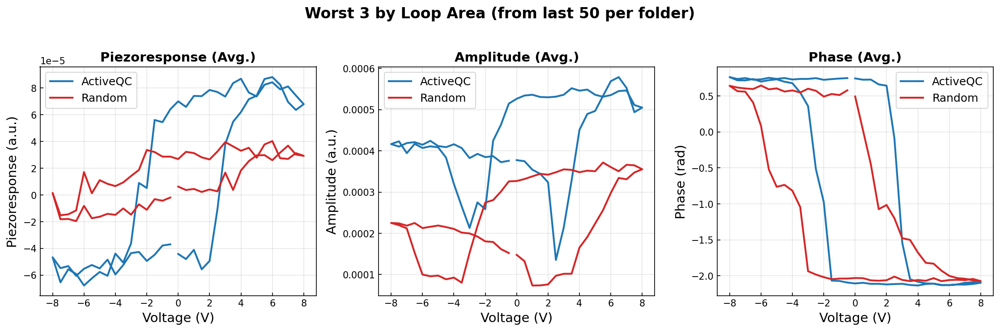

In [10]:
def loop_area(vdc, piezo):
    """Compute the enclosed area of the piezoresponse hysteresis loop (shoelace formula)."""
    return 0.5 * np.abs(np.sum(vdc[:-1] * piezo[1:] - vdc[1:] * piezo[:-1]))
    
base_dir = DATA
groups = {
    'ActiveQC': ['v2', 'v2b', 'v2c'],
    'Random': ['v2d', 'v2e', 'v2f'],
}
colors = ['tab:blue', 'tab:red']
## 3 regions * 50 per region = 150 spectra
## 2% of 150 = 3
## n_worst = 3
n_last = 50
n_worst = 3

# Collect data for each group, pick worst 10 by loop area
group_data = {}
for group_label, folder_list in groups.items():
    candidates = []
    for folder_name in folder_list:
        folder_path = os.path.join(base_dir, folder_name)
        last_files = get_last_n_files(folder_path, n=n_last, allowed=allowed_beps_files[folder_name])
        for idx, fpath in last_files:
            vdc, piezo, amps_off, phases_off = get_piezoresponse(fpath)
            area = loop_area(vdc, piezo)
            candidates.append((area, piezo, amps_off, phases_off))
    candidates.sort(key=lambda x: x[0])
    worst = candidates[:n_worst]
    group_data[group_label] = {
        'vdc': vdc,
        'piezo': np.mean([w[1] for w in worst], axis=0),
        'amps': np.mean([w[2] for w in worst], axis=0),
        'phases': np.mean([w[3] for w in worst], axis=0),
    }

# Plot 3 subplots: Piezoresponse, Amplitude, Phase
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
titles = ['Piezoresponse (Avg.)', 'Amplitude (Avg.)', 'Phase (Avg.)']
keys = ['piezo', 'amps', 'phases']
ylabels = ['Piezoresponse (a.u.)', 'Amplitude (a.u.)', 'Phase (rad)']

for ax, title, key, ylabel in zip(axes, titles, keys, ylabels):
    for (group_label, data), color in zip(group_data.items(), colors):
        ax.plot(data['vdc'], data[key], linewidth=2, color=color, label=group_label)
    ax.set_xlabel('Voltage (V)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.tick_params(direction='in')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Worst {n_worst} by Loop Area (from last {n_last} per folder)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_avg_piezo_amp_phase_grouped_worst.png', dpi=300, bbox_inches='tight')
plt.show()

===============> 75
===============> 102
===============> 91
===============> 130
===============> 130
===============> 130


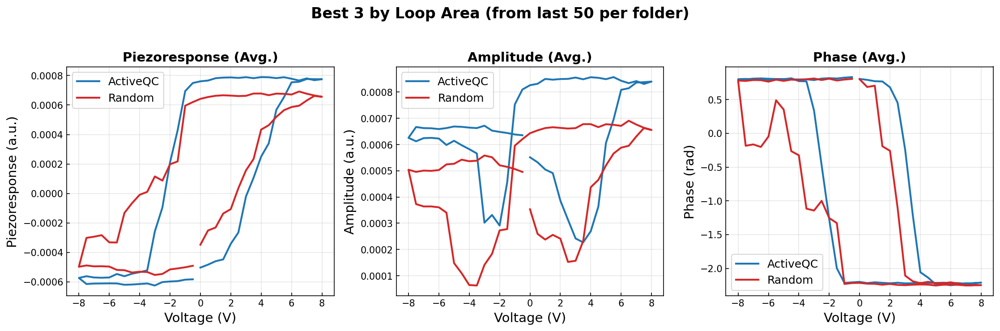

In [11]:
def loop_area(vdc, piezo):
    """Compute the enclosed area of the piezoresponse hysteresis loop (shoelace formula)."""
    return 0.5 * np.abs(np.sum(vdc[:-1] * piezo[1:] - vdc[1:] * piezo[:-1]))
    
base_dir = DATA
groups = {
    'ActiveQC': ['v2', 'v2b', 'v2c'],
    'Random': ['v2d', 'v2e', 'v2f'],
}
colors = ['tab:blue', 'tab:red']
## 3 regions * 50 per region = 150 spectra
## 2% of 150 = 3
## n_best = 3
n_last = 50
n_best = 3

# Collect data for each group, pick worst 10 by loop area
group_data = {}
for group_label, folder_list in groups.items():
    candidates = []
    for folder_name in folder_list:
        folder_path = os.path.join(base_dir, folder_name)
        last_files = get_last_n_files(folder_path, n=n_last, allowed=allowed_beps_files[folder_name])
        for idx, fpath in last_files:
            vdc, piezo, amps_off, phases_off = get_piezoresponse(fpath)
            area = loop_area(vdc, piezo)
            candidates.append((area, piezo, amps_off, phases_off))
    candidates.sort(key=lambda x: x[0])
    worst = candidates[-n_best:] 
    group_data[group_label] = {
        'vdc': vdc,
        'piezo': np.mean([w[1] for w in worst], axis=0),
        'amps': np.mean([w[2] for w in worst], axis=0),
        'phases': np.mean([w[3] for w in worst], axis=0),
    }

# Plot 3 subplots: Piezoresponse, Amplitude, Phase
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
titles = ['Piezoresponse (Avg.)', 'Amplitude (Avg.)', 'Phase (Avg.)']
keys = ['piezo', 'amps', 'phases']
ylabels = ['Piezoresponse (a.u.)', 'Amplitude (a.u.)', 'Phase (rad)']

for ax, title, key, ylabel in zip(axes, titles, keys, ylabels):
    for (group_label, data), color in zip(group_data.items(), colors):
        ax.plot(data['vdc'], data[key], linewidth=2, color=color, label=group_label)
    ax.set_xlabel('Voltage (V)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.tick_params(direction='in')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Best {n_best} by Loop Area (from last {n_last} per folder)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_avg_piezo_amp_phase_grouped_best.png', dpi=300, bbox_inches='tight')
plt.show()

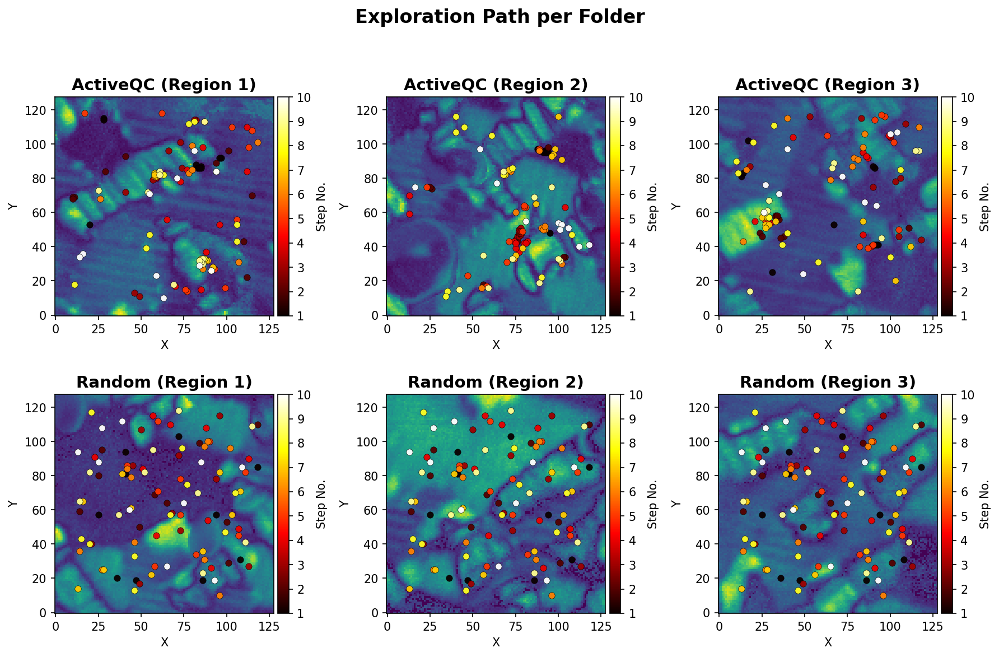

In [12]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

folders_row1 = ['v2', 'v2b', 'v2c']
folders_row2 = ['v2d', 'v2e', 'v2f']

cmap = mpl.colormaps.get_cmap("hot")
norm = mpl.colors.Normalize(vmin=1, vmax=10)

d_folder_vs_title = {
    'v2': 'ActiveQC (Region 1)',
    'v2b': 'ActiveQC (Region 2)',
    'v2c': 'ActiveQC (Region 3)',
    'v2d': 'Random (Region 1)',
    'v2e': 'Random (Region 2)',
    'v2f': 'Random (Region 3)',    
}
for row_idx, folder_list in enumerate([folders_row1, folders_row2]):
    for col_idx, folder in enumerate(folder_list):
        ax = axes[row_idx, col_idx]
        
        # Load structure image
        struc_img = np.load(os.path.join(DATA, folder, 'structure_image.npy'))
        struc_img = (struc_img - struc_img.min()) / (struc_img.max() - struc_img.min())

        # p5, p95 = np.percentile(struc_img, [1, 99])
        # struc_img = np.clip(struc_img, p5, p95)
        # struc_img = (struc_img - struc_img.min()) / (struc_img.max() - struc_img.min())        
        
        # Load coords from record0
        data0 = np.load(os.path.join(DATA, folder, 'record0.npz'), allow_pickle=True)
        coords_2d = data0['coords'].reshape(-1, 2)
        
        ax.imshow(struc_img, origin='lower', cmap='viridis')
        
        # Plot exploration path step by step (1 to 10 for display)
        for step in range(10):
            rec = np.load(os.path.join(DATA, folder, f'record{step}.npz'), allow_pickle=True)
            sel_idx = rec['nextpoint']
            pts = coords_2d[sel_idx]
            ax.scatter(pts[:, 1], pts[:, 0],
                       s=30, c=[cmap(norm(step + 1))],
                       alpha=0.95, edgecolors='k', linewidths=0.3)
        
        ax.set_title(d_folder_vs_title[folder], fontsize=14, fontweight='bold')
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        
        # Colorbar matched to image height
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        fig.colorbar(sm, cax=cax, label="Step No.")

fig.suptitle("Exploration Path per Folder", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_exploration_paths.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
folders

['v2', 'v2b', 'v2c', 'v2d', 'v2e', 'v2f']

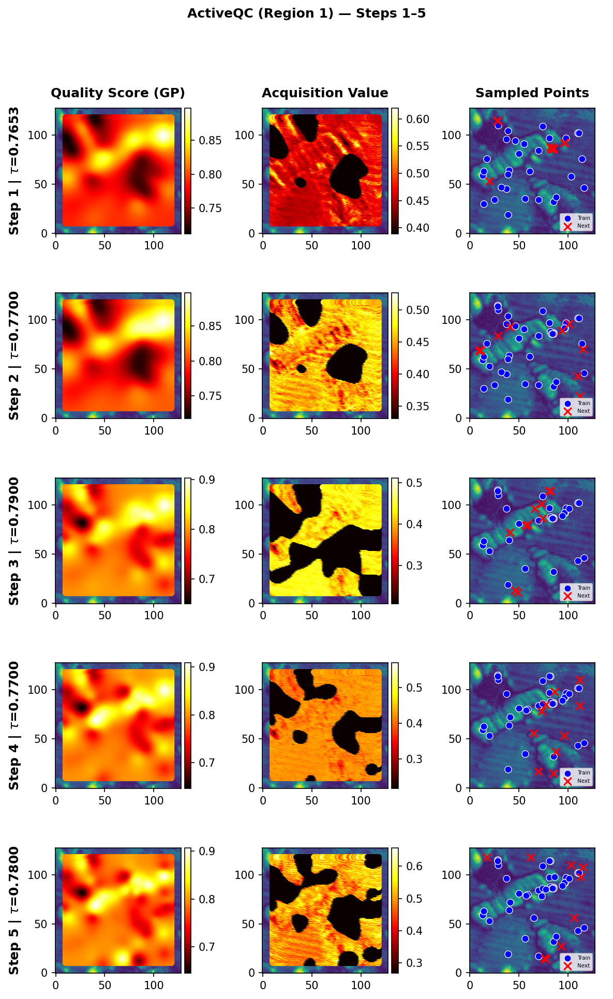

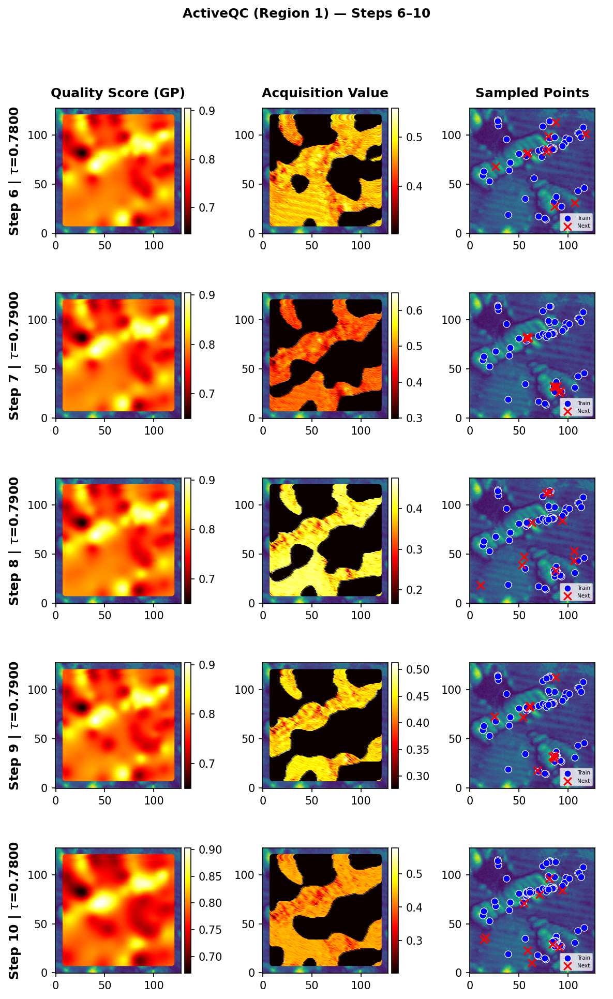

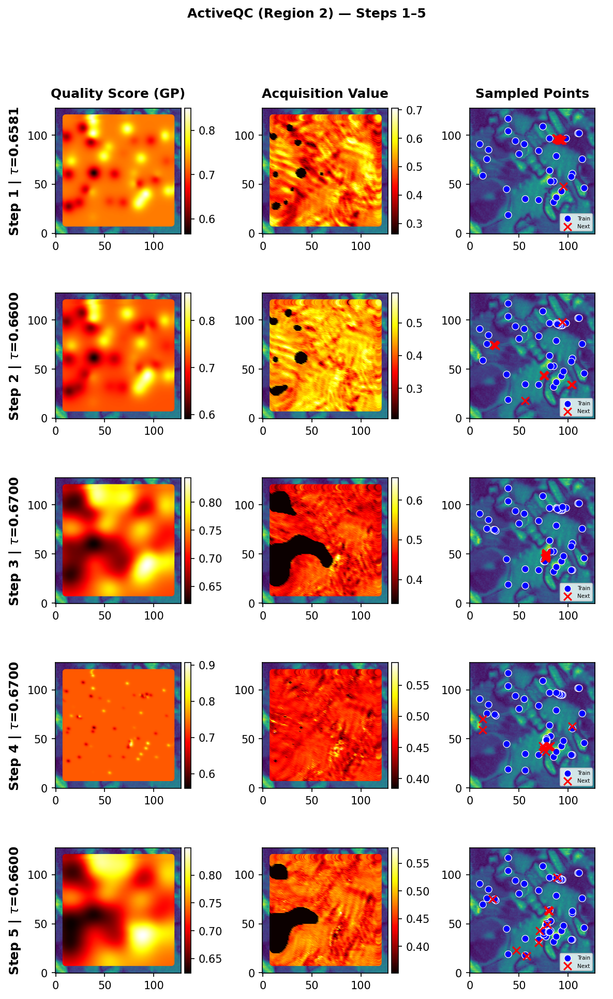

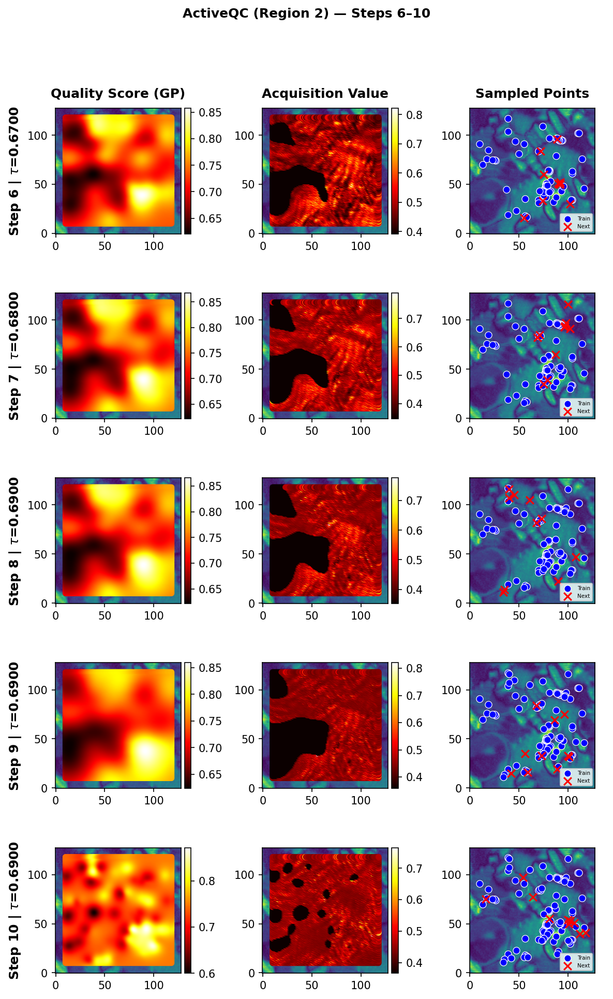

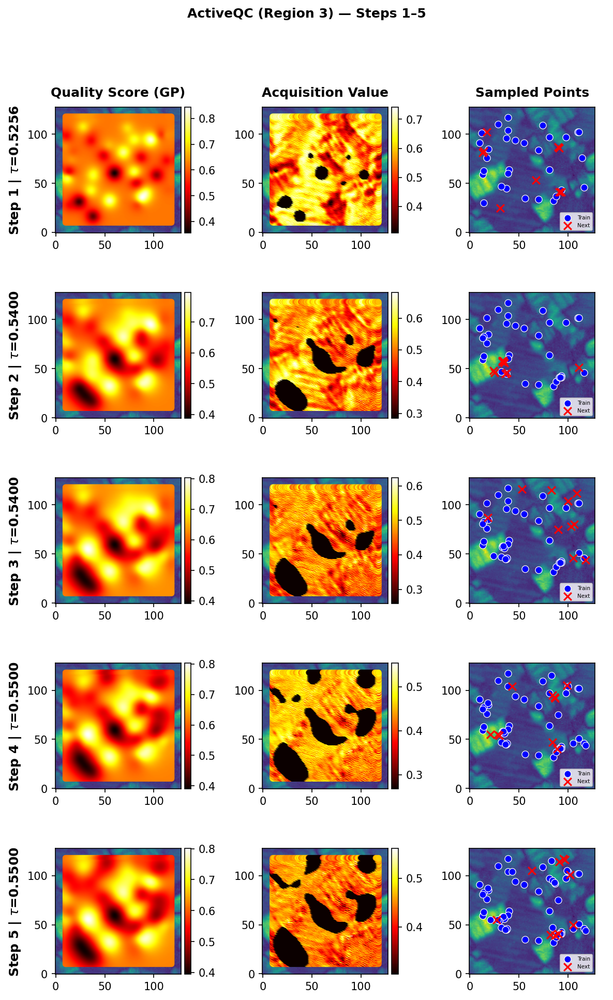

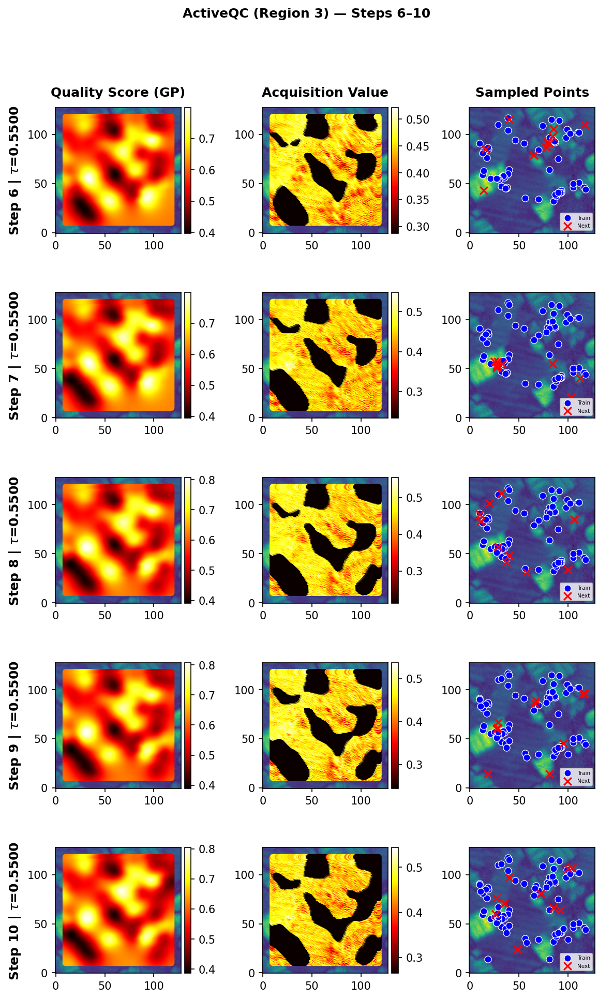

In [14]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

d_folder_vs_title = {
    'v2': 'ActiveQC (Region 1)',
    'v2b': 'ActiveQC (Region 2)',
    'v2c': 'ActiveQC (Region 3)',
}

for folder in folders[:3]:
    # Load structure image
    struc_img = np.load(os.path.join(DATA, folder, 'structure_image.npy'))
    struc_img = (struc_img - struc_img.min()) / (struc_img.max() - struc_img.min())
    
    # Two figures: steps 0-4 (display 1-5) and steps 5-9 (display 6-10)
    for fig_idx, step_range in enumerate([range(0, 5), range(5, 10)]):
        fig, axes = plt.subplots(5, 3, figsize=(8, 13), dpi=150)
        
        step_labels = [s + 1 for s in step_range]
        fig.suptitle(
            f"{d_folder_vs_title[folder]} — Steps {step_labels[0]}–{step_labels[-1]}",
            fontsize=12, fontweight="bold", y=1.0
        )
        
        col_titles = ["Quality Score (GP)", "Acquisition Value", "Sampled Points"]
        for col_idx, title in enumerate(col_titles):
            axes[0, col_idx].set_title(title, fontsize=12, fontweight="bold", pad=10)
        
        for row_idx, step in enumerate(step_range):
            data = np.load(os.path.join(DATA, folder, f'record{step}.npz'), allow_pickle=True)
            
            coords = data["coords"]
            indices_train = data["indice_train"]
            selected_indices = data["nextpoint"]
            indices_test = data["indice_test"]
            acquisition_values = data["var"]
            r2_threshold = float(data["r2_threshold"])
            coordsXY = data["coordsXY"]
            gpPred = data["gpPred"]
            
            coords_2d = coords.reshape(-1, 2)
            train_coords = coords_2d[indices_train]
            next_coords = coords_2d[selected_indices]
            test_coords = coords_2d[indices_test]
            
            # Row label
            axes[row_idx, 0].set_ylabel(
                f"Step {step+1} | $\\tau$={r2_threshold:.4f}",
                fontsize=12, fontweight="bold"
            )
            
            # (a) Quality Score (GP)
            ax = axes[row_idx, 0]
            ax.imshow(struc_img, origin="lower", cmap="viridis")
            sc = ax.scatter(coordsXY[:, 0], coordsXY[:, 1],
                            c=gpPred, s=20, cmap="hot")
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(sc, cax=cax)
            
            # (b) Acquisition Value
            ax = axes[row_idx, 1]
            ax.imshow(struc_img, origin="lower", cmap="viridis")
            sc = ax.scatter(test_coords[:, 1], test_coords[:, 0],
                            c=acquisition_values, s=20, cmap="hot")
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            fig.colorbar(sc, cax=cax)
            
            # (c) Sampled Points — add invisible colorbar to match width
            ax = axes[row_idx, 2]
            ax.imshow(struc_img, origin="lower", cmap="viridis")
            ax.scatter(train_coords[:, 1], train_coords[:, 0],
                       c="blue", s=40, edgecolors="white", linewidths=0.6, label="Train")
            ax.scatter(next_coords[:, 1], next_coords[:, 0],
                       c="red", s=50, marker="x", linewidths=1.5, label="Next")
            ax.legend(frameon=True, fontsize=5, loc="lower right")
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cax.axis("off")
        
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.savefig(f"fig_{folder}_steps_{step_labels[0]}to{step_labels[-1]}.png", dpi=300, bbox_inches="tight")
        plt.show()
